# Ch11 建模入門(Introduction to Modeling)

**對應原書**:Chapter 11 & 12(建模方法)
**軟體替代**:ModelQ 物理方塊 → 從物理方程建 DC 馬達模型(python-control)+ 逐樣本模擬交叉驗證

## 學習目標
1. 從物理方程推導 DC 馬達完整模型(電氣 + 機械)。
2. 學會**降階**:何時可以忽略電感?
3. 用兩條獨立路徑(解析 TF vs 數值積分)交叉驗證模型 —— 建模工作的基本紀律。

## 物理方程
$$L\frac{di}{dt} = V - Ri - K_e\omega, \qquad J\frac{d\omega}{dt} = K_t i - b\omega$$

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

電氣時間常數 τe = 1.00 ms(極點 1000 rad/s ≈ 159 Hz)
機械時間常數 τm = 9.99 ms(極點 100 rad/s ≈ 15.9 Hz)
完整模型極點: [-887.2838+0.j -112.8162+0.j]


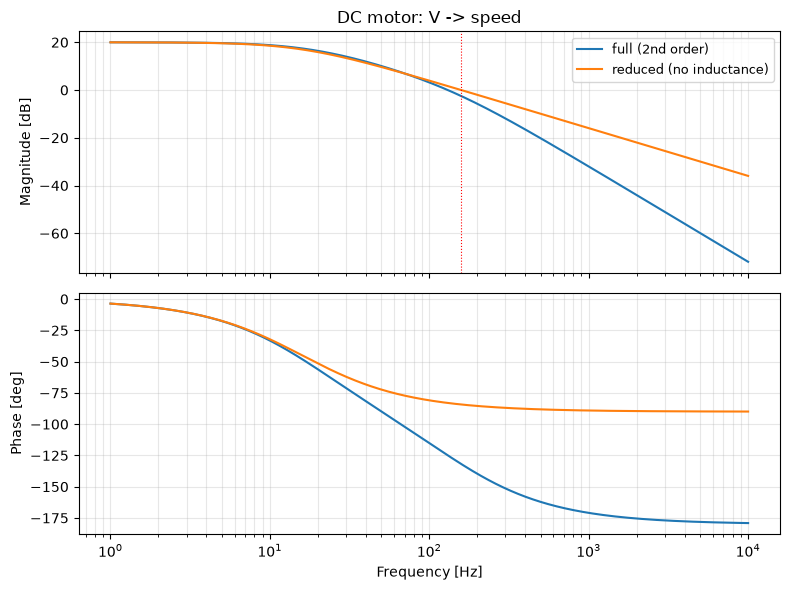

In [2]:
R, L_ind, Kt, Ke = 1.0, 1e-3, 0.1, 0.1
J, b = 1e-4, 1e-5
s = ct.tf('s')

# 完整二階模型:V -> w
P_full = Kt / ((L_ind * s + R) * (J * s + b) + Kt * Ke)
# 降階(忽略電感):V -> w
P_red = Kt / (R * (J * s + b) + Kt * Ke)

tau_e = L_ind / R
tau_m = R * J / (R * b + Kt * Ke)
print(f'電氣時間常數 τe = {tau_e*1000:.2f} ms(極點 {1/tau_e:.0f} rad/s ≈ {1/tau_e/2/np.pi:.0f} Hz)')
print(f'機械時間常數 τm = {tau_m*1000:.2f} ms(極點 {1/tau_m:.0f} rad/s ≈ {1/tau_m/2/np.pi:.1f} Hz)')
print('完整模型極點:', ct.poles(P_full))

fig, (axm, axp) = bode_compare([
    ('full (2nd order)', P_full),
    ('reduced (no inductance)', P_red),
], f_hz=np.logspace(0, 4, 600), title='DC motor: V -> speed')
axm.axvline(1 / tau_e / 2 / np.pi, color='r', ls=':', lw=0.8)
plt.show()

兩模型在電氣極點(~160 Hz)以下幾乎重合 —— 若迴路頻寬遠低於此,降階模型就夠用。
**這正是書中反覆強調的:模型只要在「你要用的頻段」正確即可。**

## 交叉驗證:解析 TF vs 逐樣本模擬

同一組微分方程、兩種完全獨立的實作(python-control 的解析步階 vs `DCMotorPlant` 的
1 µs Euler 積分)。兩者吻合,才敢說模型寫對了。

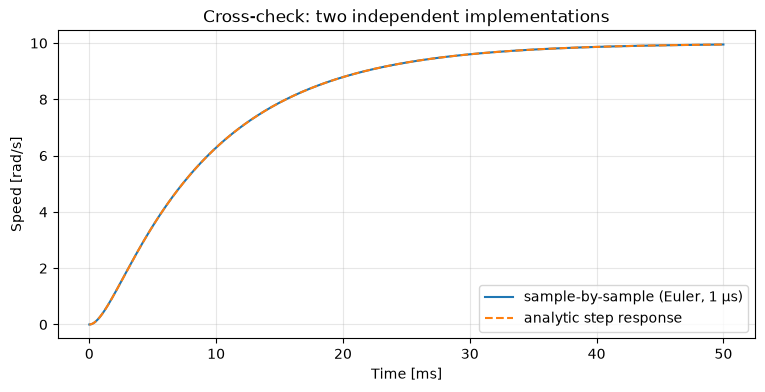

兩實作最大相對誤差:0.008%
穩態轉速:模擬 9.949 | 解析 DC 增益 9.990 rad/s


In [3]:
dt_sim = 1e-6
t_end = 0.05
n = int(t_end / dt_sim)
plant = DCMotorPlant(R=R, L=L_ind, Kt=Kt, Ke=Ke, J=J, b=b, dt=dt_sim)
w_sim = np.empty(n)
i_sim = np.empty(n)
for k in range(n):
    i_sim[k], w_sim[k] = plant.i, plant.w
    plant.step(1.0)                      # 1 V 步階
t_sim = np.arange(n) * dt_sim

t_tf, w_tf = ct.step_response(P_full, t_sim[::50])

plt.figure(figsize=(9, 4))
plt.plot(t_sim * 1000, w_sim, label='sample-by-sample (Euler, 1 µs)')
plt.plot(t_tf * 1000, w_tf, '--', label='analytic step response')
plt.xlabel('Time [ms]'); plt.ylabel('Speed [rad/s]'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Cross-check: two independent implementations')
plt.show()

w_tf_i = np.interp(t_sim, t_tf, w_tf)
max_err = float(np.max(np.abs(w_sim - w_tf_i)) / w_tf[-1])
print(f'兩實作最大相對誤差:{max_err*100:.3f}%')
print(f'穩態轉速:模擬 {w_sim[-1]:.3f} | 解析 DC 增益 {float(ct.dcgain(P_full)):.3f} rad/s')

In [4]:
# ✅ 驗證
assert max_err < 0.01                                  # 交叉驗證 < 1%
dc_full, dc_red = float(ct.dcgain(P_full)), float(ct.dcgain(P_red))
assert abs(dc_full - dc_red) / dc_full < 1e-6          # 降階不改 DC
d_f = frf_of_system(P_full, [1.0]); d_r = frf_of_system(P_red, [1.0])
assert abs(d_f['mag_db'][0] - d_r['mag_db'][0]) < 0.1  # 1 Hz:重合
d_f2 = frf_of_system(P_full, [1000.0]); d_r2 = frf_of_system(P_red, [1000.0])
assert abs(d_f2['mag_db'][0] - d_r2['mag_db'][0]) > 3  # 1 kHz:明顯分歧
assert abs(w_sim[-1] - dc_full) / dc_full < 0.01
print('Ch11 驗證通過 ✅')

Ch11 驗證通過 ✅


## 練習
1. 把電感放大 10 倍(L=10 mH),降階模型在多少 Hz 以上失效?迴路設計會受什麼影響?
2. 推導電流對電壓的轉移函數 $i/V$,驗證高頻趨近 $1/(Ls+R)$。
3. 加入負載轉矩輸入,推導 $\omega/T_{load}$ 並與 `DCMotorPlant` 模擬比對。
4. 用第 2 章的 DSA 對 `DCMotorPlant` 做 chirp 量測,疊在解析 Bode 上(這就是第 13 章的流程)。